<a href="https://colab.research.google.com/github/DevBatra05/Algorithm-for-Intelligent-Systems-and-Robotics-Lab/blob/main/Lab_3_Hill_Climbing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.animation as animation

# ---- Grid setup ----
# 0 = free cell, 1 = obstacle
grid = [
    [0, 0, 1, 0, 0, 0],
    [0, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 1, 0],
    [1, 1, 0, 1, 1, 0],
    [0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 0],
]

ROWS, COLS = len(grid), len(grid[0])
start = (0, 0)   # Point A
goal = (5, 5)    # Point G

In [6]:
def heuristic(cell, goal):
    return abs(cell[0] - goal[0]) + abs(cell[1] - goal[1])


def get_neighbors(cell):
    r, c = cell
    moves = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    neighbors = []
    for dr, dc in moves:
        nr, nc = r + dr, c + dc
        if 0 <= nr < ROWS and 0 <= nc < COLS and grid[nr][nc] == 0:
            neighbors.append((nr, nc))
    return neighbors


def hill_climbing(start, goal):
    current = start
    path = [current]
    visited = set([current])
    while current != goal:
        neighbors = [n for n in get_neighbors(current) if n not in visited]
        if not neighbors:
            return path, False
        next_cell = min(neighbors, key=lambda n: heuristic(n, goal))
        if heuristic(next_cell, goal) >= heuristic(current, goal):
            return path, False
        current = next_cell
        path.append(current)
        visited.add(current)
    return path, True


path, reached = hill_climbing(start, goal)
print("Path:", path)
print("Reached goal:", reached)

Path: [(0, 0), (1, 0), (2, 0), (2, 1), (2, 2), (3, 2), (4, 2), (4, 3), (4, 4), (4, 5), (5, 5)]
Reached goal: True


In [7]:
# ---- Animation ----
fig, ax = plt.subplots(figsize=(6, 6))

def draw_grid():
    ax.clear()
    for r in range(ROWS):
        for c in range(COLS):
            color = "#2b2b2b" if grid[r][c] == 1 else "#f0f0f0"
            ax.add_patch(patches.Rectangle((c, ROWS - 1 - r), 1, 1, facecolor=color, edgecolor="gray"))
    sr, sc = start
    gr, gc = goal
    ax.add_patch(patches.Rectangle((sc, ROWS - 1 - sr), 1, 1, facecolor="#51cf66", edgecolor="black"))
    ax.text(sc + 0.5, ROWS - 1 - sr + 0.5, "A", ha="center", va="center", fontsize=14, fontweight="bold")
    ax.add_patch(patches.Rectangle((gc, ROWS - 1 - gr), 1, 1, facecolor="#ff6b6b", edgecolor="black"))
    ax.text(gc + 0.5, ROWS - 1 - gr + 0.5, "G", ha="center", va="center", fontsize=14, fontweight="bold")
    ax.set_xlim(0, COLS)
    ax.set_ylim(0, ROWS)
    ax.set_xticks([])
    ax.set_yticks([])

def update(frame):
    draw_grid()
    # trail so far (yellow)
    for (r, c) in path[1:frame]:
        ax.add_patch(patches.Rectangle((c, ROWS - 1 - r), 1, 1, facecolor="#ffd43b", edgecolor="gray"))
    # current moving point (blue circle) — this is the "point going from A to G"
    r, c = path[frame]
    ax.add_patch(patches.Circle((c + 0.5, ROWS - 1 - r + 0.5), 0.28, facecolor="#1c7ed6", edgecolor="black", zorder=5))
    ax.set_title(f"Hill Climbing: Step {frame} / {len(path)-1}")
    return []

anim = animation.FuncAnimation(fig, update, frames=len(path), interval=600, repeat=True)
anim.save("hill_climbing_animation.gif", writer="pillow", fps=1.5)
plt.close()
print("Saved: hill_climbing_animation.gif")

Saved: hill_climbing_animation.gif


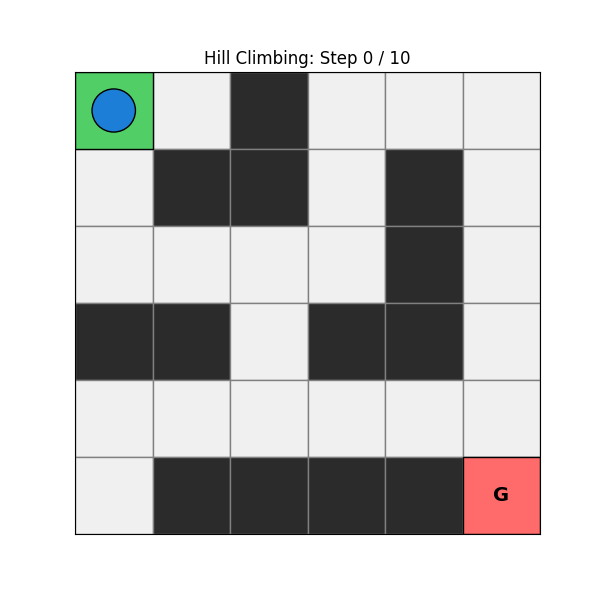

In [8]:
from IPython.display import Image as IPImage
IPImage("hill_climbing_animation.gif")

Path: [(0, 0), (1, 0), (2, 0), (2, 1), (2, 2), (3, 2), (4, 2), (4, 3), (4, 4), (4, 5), (5, 5)]
Heuristic values at each step: [10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]


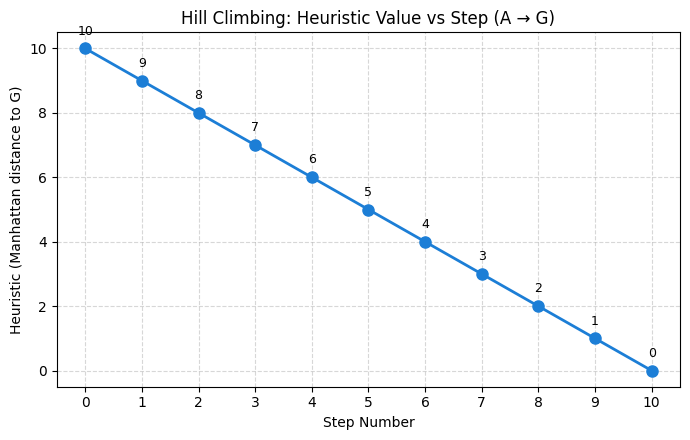

/tmp/ipykernel_660/1254173385.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


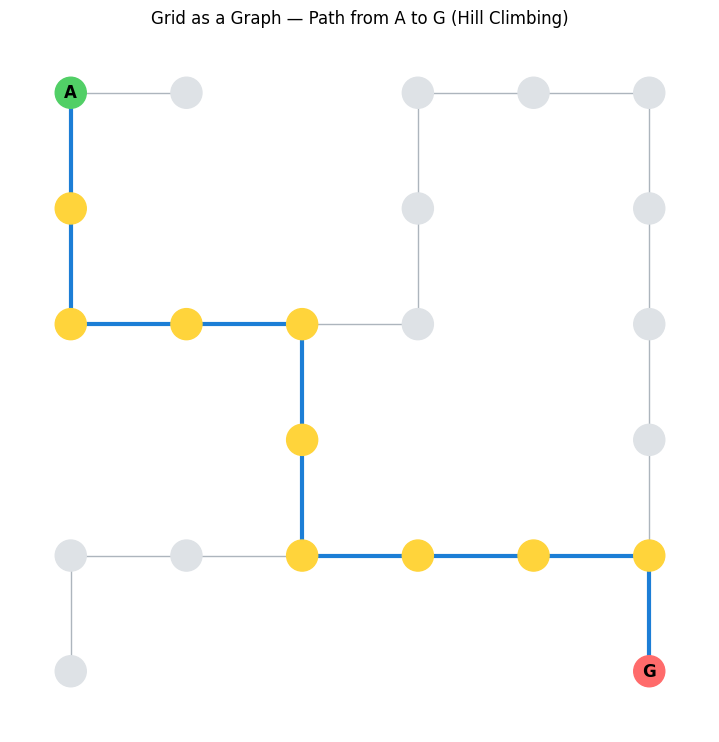


Saved: heuristic_vs_step.png, grid_as_graph.png


In [9]:
import matplotlib.pyplot as plt
import networkx as nx

# ---- Grid setup (same as before) ----
grid = [
    [0, 0, 1, 0, 0, 0],
    [0, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 1, 0],
    [1, 1, 0, 1, 1, 0],
    [0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 0],
]
ROWS, COLS = len(grid), len(grid[0])
start = (0, 0)
goal = (5, 5)

def heuristic(cell, goal):
    return abs(cell[0] - goal[0]) + abs(cell[1] - goal[1])

def get_neighbors(cell):
    r, c = cell
    moves = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    neighbors = []
    for dr, dc in moves:
        nr, nc = r + dr, c + dc
        if 0 <= nr < ROWS and 0 <= nc < COLS and grid[nr][nc] == 0:
            neighbors.append((nr, nc))
    return neighbors

def hill_climbing(start, goal):
    current = start
    path = [current]
    visited = set([current])
    while current != goal:
        neighbors = [n for n in get_neighbors(current) if n not in visited]
        if not neighbors:
            return path, False
        next_cell = min(neighbors, key=lambda n: heuristic(n, goal))
        if heuristic(next_cell, goal) >= heuristic(current, goal):
            return path, False
        current = next_cell
        path.append(current)
        visited.add(current)
    return path, True

path, reached = hill_climbing(start, goal)
h_values = [heuristic(cell, goal) for cell in path]
print("Path:", path)
print("Heuristic values at each step:", h_values)

# ---- Graph 1: Heuristic value vs Step (the actual "hill" being descended) ----
plt.figure(figsize=(7, 4.5))
plt.plot(range(len(h_values)), h_values, marker='o', color='#1c7ed6', linewidth=2, markersize=8)
for i, h in enumerate(h_values):
    plt.annotate(str(h), (i, h), textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9)
plt.title("Hill Climbing: Heuristic Value vs Step (A \u2192 G)")
plt.xlabel("Step Number")
plt.ylabel("Heuristic (Manhattan distance to G)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(range(len(h_values)))
plt.tight_layout()
plt.savefig("heuristic_vs_step.png", dpi=150, bbox_inches="tight")
plt.show()

# ---- Graph 2: Grid as a network graph (nodes = free cells, edges = adjacency) ----
G = nx.grid_2d_graph(ROWS, COLS)
# remove obstacle nodes
for r in range(ROWS):
    for c in range(COLS):
        if grid[r][c] == 1:
            G.remove_node((r, c))

pos = {(r, c): (c, ROWS - 1 - r) for (r, c) in G.nodes()}

plt.figure(figsize=(7, 7))
node_colors = []
for n in G.nodes():
    if n == start:
        node_colors.append("#51cf66")
    elif n == goal:
        node_colors.append("#ff6b6b")
    elif n in path:
        node_colors.append("#ffd43b")
    else:
        node_colors.append("#dee2e6")

nx.draw(G, pos, node_color=node_colors, node_size=500, edge_color="#adb5bd", with_labels=False)

# highlight path edges
path_edges = list(zip(path, path[1:]))
nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color="#1c7ed6", width=3)

labels = {n: ("A" if n == start else "G" if n == goal else "") for n in G.nodes()}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=12, font_weight="bold")

plt.title("Grid as a Graph — Path from A to G (Hill Climbing)")
plt.axis("off")
plt.tight_layout()
plt.savefig("grid_as_graph.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nSaved: heuristic_vs_step.png, grid_as_graph.png")

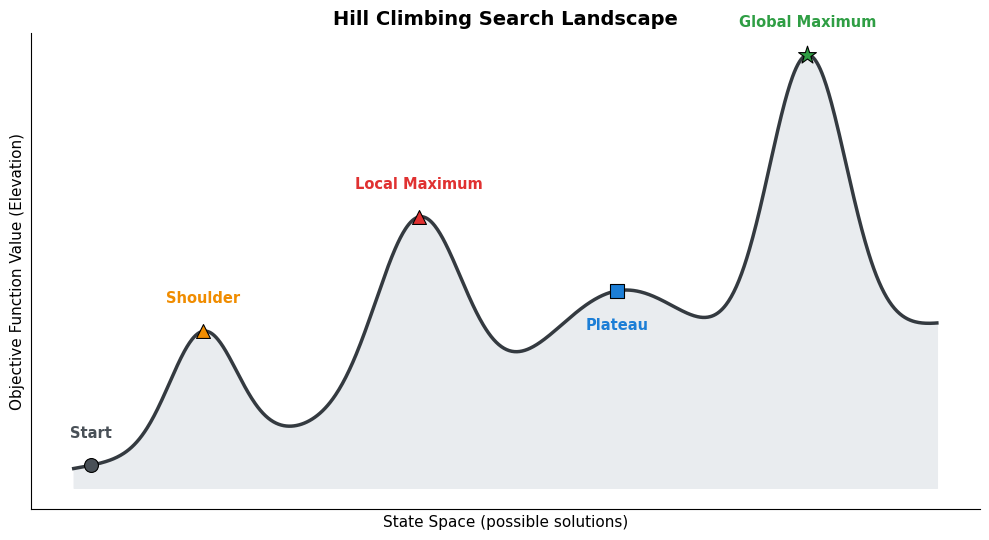

Saved: hill_climbing_landscape.png


In [10]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 10, 1000)

# Build a landscape with: a shoulder, a local maximum, a flat plateau, and a global maximum
y = (
    1.2 * np.exp(-((x - 1.5) ** 2) / 0.3)      # small bump (local max #1)
    + 2.0 * np.exp(-((x - 4) ** 2) / 0.5)       # local maximum
    + 0.9 * np.exp(-((x - 6.3) ** 2) / 1.2)     # plateau-ish flat region
    + 3.0 * np.exp(-((x - 8.5) ** 2) / 0.4)     # global maximum
    + 0.15 * x
)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(x, y, color="#343a40", linewidth=2.5)
ax.fill_between(x, y, y.min() - 0.2, color="#e9ecef")

# ---- Identify and label key points ----
local_max1_idx = np.argmin(np.abs(x - 1.5))
local_max2_idx = np.argmin(np.abs(x - 4))
plateau_idx = np.argmin(np.abs(x - 6.3))
global_max_idx = np.argmin(np.abs(x - 8.5))
start_idx = np.argmin(np.abs(x - 0.2))

points = [
    (start_idx, "Start", "#495057", "o"),
    (local_max1_idx, "Shoulder", "#f08c00", "^"),
    (local_max2_idx, "Local Maximum", "#e03131", "^"),
    (plateau_idx, "Plateau", "#1c7ed6", "s"),
    (global_max_idx, "Global Maximum", "#2f9e44", "*"),
]

for idx, label, color, marker in points:
    ax.scatter(x[idx], y[idx], color=color, s=180 if marker == "*" else 100,
               marker=marker, zorder=5, edgecolor="black", linewidth=0.8)
    offset = 0.25 if label != "Plateau" else -0.35
    ax.annotate(label, (x[idx], y[idx]), textcoords="offset points",
                xytext=(0, 20 if offset > 0 else -28), ha="center",
                fontsize=10.5, fontweight="bold", color=color)

ax.set_xlabel("State Space (possible solutions)", fontsize=11)
ax.set_ylabel("Objective Function Value (Elevation)", fontsize=11)
ax.set_title("Hill Climbing Search Landscape", fontsize=14, fontweight="bold")
ax.set_xticks([])
ax.set_yticks([])
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig("hill_climbing_landscape.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: hill_climbing_landscape.png")

Free cells (state space): 23
Local maxima found (would trap hill climbing): [(0, 1), (2, 3), (5, 0)]
Plateau cells found (equal-valued neighbors): []
Global maximum (goal): (5, 5) objective = 0

Path actually taken: [(0, 0), (1, 0), (2, 0), (2, 1), (2, 2), (3, 2), (4, 2), (4, 3), (4, 4), (4, 5), (5, 5)]
Objective values along path: [-10, -9, -8, -7, -6, -5, -4, -3, -2, -1, 0]


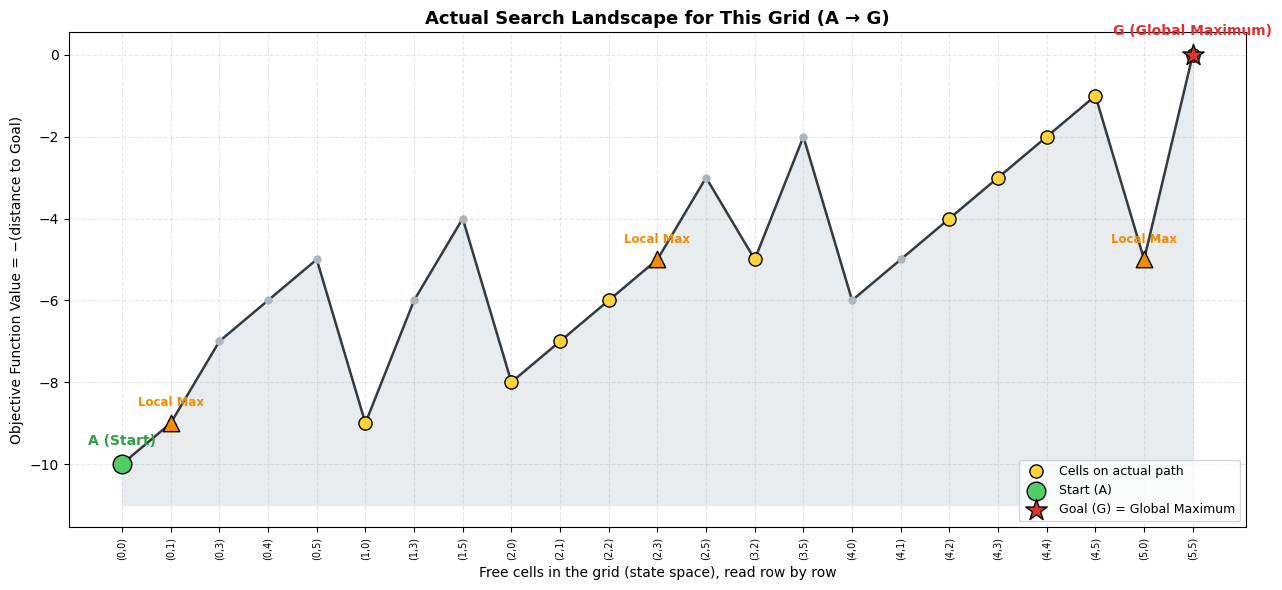


Saved: hill_climbing_real_landscape.png


In [11]:
import matplotlib.pyplot as plt
import numpy as np

# ---- Same grid, same heuristic, same functions as your notebook ----
grid = [
    [0, 0, 1, 0, 0, 0],
    [0, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 1, 0],
    [1, 1, 0, 1, 1, 0],
    [0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 0],
]
ROWS, COLS = len(grid), len(grid[0])
start = (0, 0)
goal = (5, 5)

def heuristic(cell, goal):
    return abs(cell[0] - goal[0]) + abs(cell[1] - goal[1])

def get_neighbors(cell):
    r, c = cell
    moves = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    neighbors = []
    for dr, dc in moves:
        nr, nc = r + dr, c + dc
        if 0 <= nr < ROWS and 0 <= nc < COLS and grid[nr][nc] == 0:
            neighbors.append((nr, nc))
    return neighbors

def hill_climbing(start, goal):
    current = start
    path = [current]
    visited = set([current])
    while current != goal:
        neighbors = [n for n in get_neighbors(current) if n not in visited]
        if not neighbors:
            return path, False
        next_cell = min(neighbors, key=lambda n: heuristic(n, goal))
        if heuristic(next_cell, goal) >= heuristic(current, goal):
            return path, False
        current = next_cell
        path.append(current)
        visited.add(current)
    return path, True

path, reached = hill_climbing(start, goal)

# ---- Objective function: higher = better = closer to goal ----
# objective(cell) = -heuristic(cell, goal)   (so the goal is the highest point, i.e. the "peak")
def objective(cell):
    return -heuristic(cell, goal)

# ---- Build the REAL landscape: every free cell in the grid, in row-major order ----
free_cells = [(r, c) for r in range(ROWS) for c in range(COLS) if grid[r][c] == 0]
x_labels = [f"({r},{c})" for r, c in free_cells]
y_values = [objective(cell) for cell in free_cells]

# ---- Find REAL local maxima and plateaus using actual grid adjacency ----
local_maxima = []
plateaus = []
for cell in free_cells:
    neighbors = get_neighbors(cell)
    if not neighbors:
        continue
    neighbor_vals = [objective(n) for n in neighbors]
    if objective(cell) >= max(neighbor_vals) and cell != goal:
        if objective(cell) == max(neighbor_vals):
            plateaus.append(cell)
        else:
            local_maxima.append(cell)

print("Free cells (state space):", len(free_cells))
print("Local maxima found (would trap hill climbing):", local_maxima)
print("Plateau cells found (equal-valued neighbors):", plateaus)
print("Global maximum (goal):", goal, "objective =", objective(goal))
print("\nPath actually taken:", path)
print("Objective values along path:", [objective(c) for c in path])

# ---- Plot ----
fig, ax = plt.subplots(figsize=(13, 6))
xs = range(len(free_cells))
ax.plot(xs, y_values, color="#343a40", linewidth=1.8, zorder=2)
ax.fill_between(xs, y_values, min(y_values) - 1, color="#e9ecef", zorder=1)

# mark all free cells
ax.scatter(xs, y_values, color="#adb5bd", s=25, zorder=3)

# mark path cells (in order actually visited)
path_x = [free_cells.index(c) for c in path]
path_y = [objective(c) for c in path]
ax.scatter(path_x, path_y, color="#ffd43b", s=90, zorder=4, edgecolor="black", label="Cells on actual path")

# mark start
start_x = free_cells.index(start)
ax.scatter(start_x, objective(start), color="#51cf66", s=180, zorder=5, edgecolor="black", marker="o", label="Start (A)")
ax.annotate("A (Start)", (start_x, objective(start)), textcoords="offset points", xytext=(0, 14),
            ha="center", fontsize=10, fontweight="bold", color="#2f9e44")

# mark goal / global maximum
goal_x = free_cells.index(goal)
ax.scatter(goal_x, objective(goal), color="#e03131", s=260, zorder=5, edgecolor="black", marker="*", label="Goal (G) = Global Maximum")
ax.annotate("G (Global Maximum)", (goal_x, objective(goal)), textcoords="offset points", xytext=(0, 14),
            ha="center", fontsize=10, fontweight="bold", color="#e03131")

# mark real local maxima
for cell in local_maxima:
    xi = free_cells.index(cell)
    ax.scatter(xi, objective(cell), color="#f08c00", s=140, zorder=5, edgecolor="black", marker="^")
    ax.annotate("Local Max", (xi, objective(cell)), textcoords="offset points", xytext=(0, 12),
                ha="center", fontsize=8.5, fontweight="bold", color="#f08c00")

# mark real plateaus
for cell in plateaus:
    xi = free_cells.index(cell)
    ax.scatter(xi, objective(cell), color="#1c7ed6", s=120, zorder=5, edgecolor="black", marker="s")
    ax.annotate("Plateau", (xi, objective(cell)), textcoords="offset points", xytext=(0, -18),
                ha="center", fontsize=8.5, fontweight="bold", color="#1c7ed6")

ax.set_xticks(xs)
ax.set_xticklabels(x_labels, rotation=90, fontsize=7)
ax.set_xlabel("Free cells in the grid (state space), read row by row", fontsize=10)
ax.set_ylabel("Objective Function Value = \u2212(distance to Goal)", fontsize=10)
ax.set_title("Actual Search Landscape for This Grid (A \u2192 G)", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig("hill_climbing_real_landscape.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: hill_climbing_real_landscape.png")